# Importing Libraries

In [3]:
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from PIL import Image
import difflib
import os

# Creating, Initial Testing of Pipeline

Going to create a cimple pipeline using this model. It will probably have to be more involved than just a couple python calls in the future, but for testing right now it's pretty convenient. Like they recommend, I'll probably end up training this on my own handwriting.

In [2]:
transfer = pipeline("image-to-text", model="microsoft/trocr-base-handwritten")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


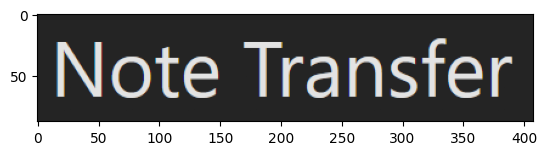

In [3]:
%matplotlib inline

image_path = r'images\test-transfer.png'
image = mpimg.imread(image_path)
image_plot = plt.imshow(image)

In [4]:
result = transfer(image_path)
text = result[0]['generated_text']
print(text)

Note Transfer


Looking pretty good! It is able to recognize text, but let's test some neat handwriting.

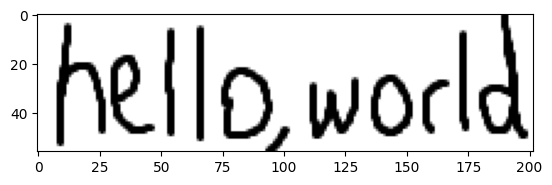

In [5]:
image_path = r'images\handwriting-test.png'
image = mpimg.imread(image_path)
image_plot = plt.imshow(image)

In [6]:
result = transfer(image_path)
text = result[0]['generated_text']
print(text)

hello , world


How about actual scanned handwriting?

In [7]:
def test_image(image_path):
    # Get image, show it
    image = mpimg.imread(image_path)
    image_plot = plt.imshow(image)
    plt.show()

    # Run trhough model, show output
    result = transfer(image_path)
    text = result[0]['generated_text']
    print(text)

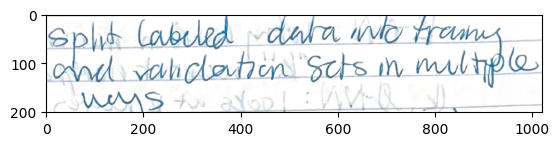

other grandchildren in multiple


In [8]:
test_image(r'images\real-handwriting-large.png')

Not really looking too great there. Not sure where it's reading. I like it had trouble with multiple lines, but I'll have to read more into the model documentation for that. Let's try out a small snippet:

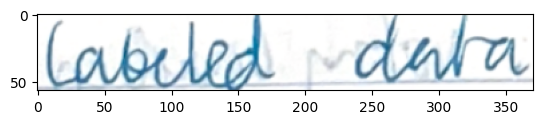

labuted pollution


In [9]:
test_image(r'images\real-handwriting-small.png')

Wow yeah that's not great. Let's see if it's the extra stuff that comes with real handwriting. I'll trace over it in paint, so it's just black and white.

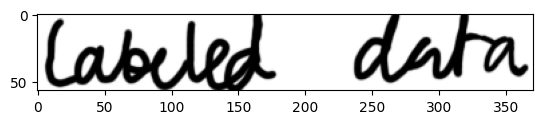

labeled data


In [10]:

test_image(r'images\real-handwriting-small-clean.png')

Okay that's good to see. See I'll definitely need to look into standardizing these images for contract, color, etc.

Doing some research with the papers of the model, I'm pretty sure we have to do text detection before text recognition. That is, this particular model is for the text recognition but not the text detection. So it can convert words and sentences into text, but not a screenshot of a whole paragraph. We'll probably have to use Yolo for segmentation of the sentences. The nano model will work for that most likely, and is fairly easy to run.

# Cleaning Images

Now that we know it can detect pretty well, before getting into segmentation, we'll figure out how to clean the images for text recognition. OpenCV should be pretty useful for that.

In [11]:
import cv2

In [12]:
def show_cv2_img(image):
    plt_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(plt_image)

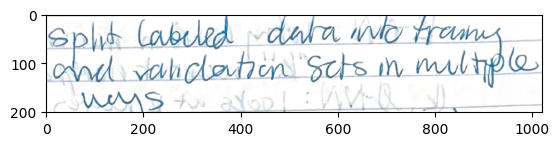

In [13]:
# Load test image
image = cv2.imread(r'images\real-handwriting-large.png')
show_cv2_img(image)

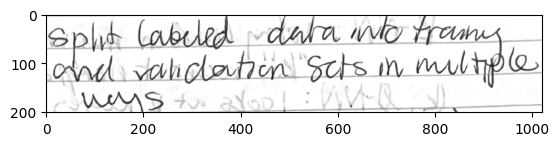

In [14]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

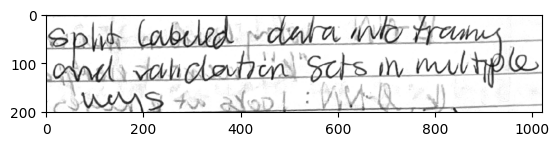

In [15]:
# Enhance contrast (CLAHE)
def enchance_contrast(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(image)
    return enhanced

enhanced = enchance_contrast(gray)
plt.imshow(enhanced, cmap='gray')

Honestly looks like it's enhancing the stuff behind it. Maybe we'll try some other techniques individually before applying the contrast

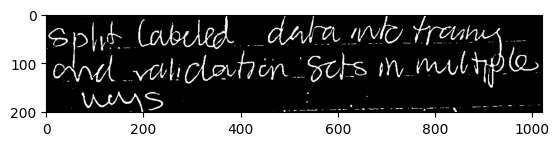

In [16]:
# Adative threshold
def apply_adaptive_threshold(image):
    return cv2.adaptiveThreshold(
        image, 255, 
        cv2.ADAPTIVE_THRESH_MEAN_C, 
        cv2.THRESH_BINARY_INV, 
        blockSize=15, C=50
    )

adaptive = apply_adaptive_threshold(gray)
plt.imshow(adaptive, cmap='gray')

This is definitely showing a lot more promise. It does remove the dots from the 'i's, but surely the model can account for that pretty well. The lines also like to stick around, but I think we can deal with that (and hopefully the model can too).

Let;s look at other options still, just to evaluate.

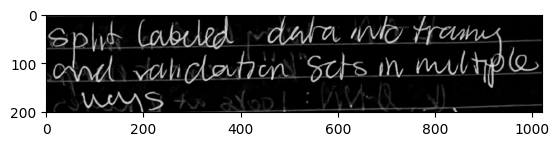

In [17]:
# Background estimation, then subtraction
def subtract_background(image): 
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 30))
    background = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
    diff = cv2.absdiff(background, image)
    return diff

diff = subtract_background(gray)
plt.imshow(diff, cmap='gray')

That looks pretty similar, maybe combined with the adaptive threshold then that could be good. Let's see when the denoising does, and then we can start combining them together.

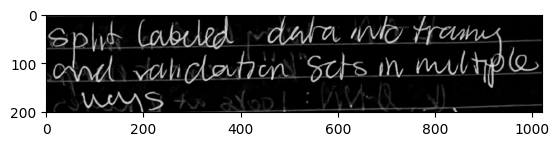

In [18]:
# Blurring
def apply_blur(image):
    cleaned = cv2.medianBlur(image, 1)
    return cleaned

cleaned = apply_blur(gray)
plt.imshow(diff, cmap='gray')

This really only gets smaller, fine-grained notes so not sure if it'll really be that noticeable

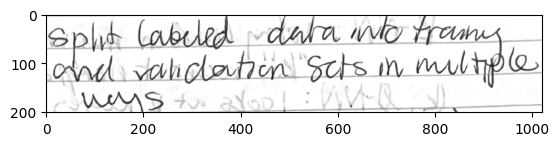

In [19]:
def filter_specs(image):
    cleaned = image.copy()
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        if cv2.contourArea(cnt) < 15:
            cv2.drawContours(cleaned, [cnt], -1, 0, -1)
    return cleaned

cleaned = filter_specs(gray)
plt.imshow(cleaned, cmap='gray')

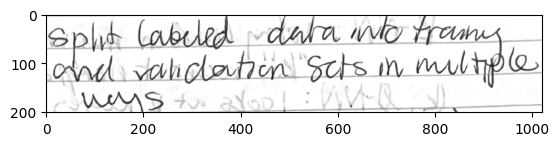

In [20]:
plt.imshow(gray, cmap='gray')

Yeah maybe not the biggest difference with those last few, but combined together to filter out some noise with the final ones, it think it'll go well.

Let's combine them now!

In [21]:
# For making the detected lineds a littel larger
def dilate(image):
    return cv2.dilate(
        image,
        np.ones((2, 2), np.uint8),
        iterations=1
    )

In [22]:
def full_filter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    adapted = apply_adaptive_threshold(gray)
    filtered = filter_specs(adapted)
    dilated = dilate(filtered)
    blurred = apply_blur(dilated)
    final = cv2.bitwise_not(blurred)
    return final
    

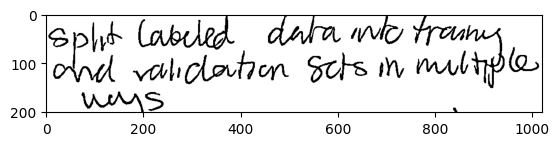

In [23]:
filtered = full_filter(image)
plt.imshow(filtered, cmap='gray')

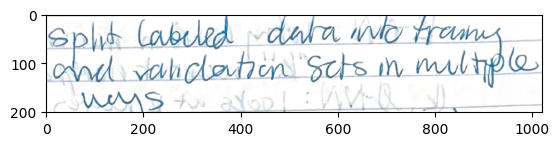

In [24]:
show_cv2_img(image)

That looks pretty good! Let's see how it works with the other parts, and then let's try a whole page!

-------images\real-handwriting-small.png---------
-------images\whole-page.png---------


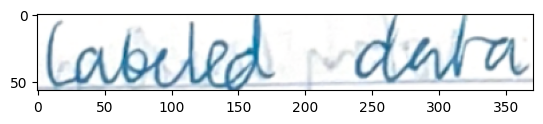

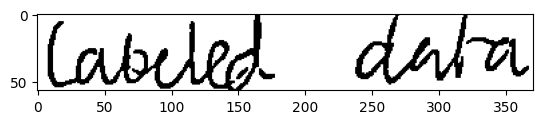

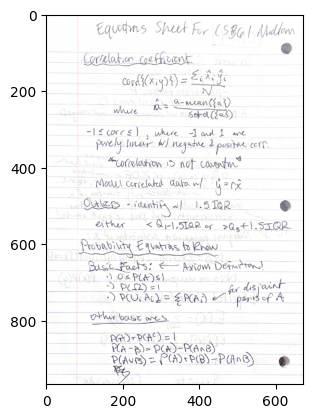

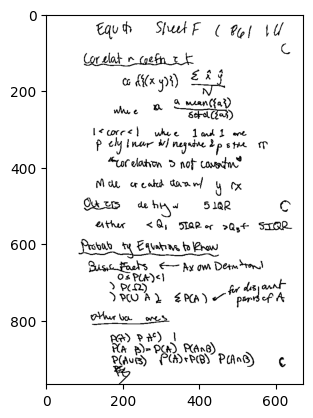

<Figure size 640x480 with 0 Axes>

In [25]:
image_paths = [
    r"images\real-handwriting-small.png",
    r"images\whole-page.png"
]

for image_path in image_paths:
    image = cv2.imread(image_path)
    print(f"-------{image_path}---------")
    show_cv2_img(image)
    filtered = full_filter(image)
    plt.figure()
    plt.imshow(filtered, cmap='gray')
    plt.figure()

Seeming to be losing some information here in the larger, but it's also doing a decent job with the smaller one. Maybe we can tweak things a little more, either now of later. Remember, we'll only have to do smaller lines which is good. Let's see if we take a smaller subset, that we lose the same information

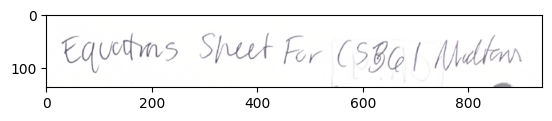

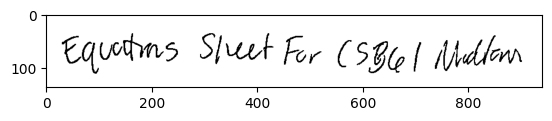

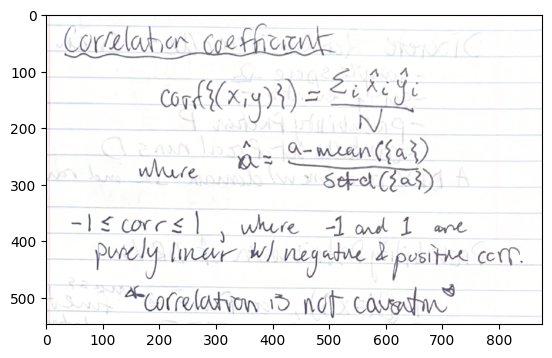

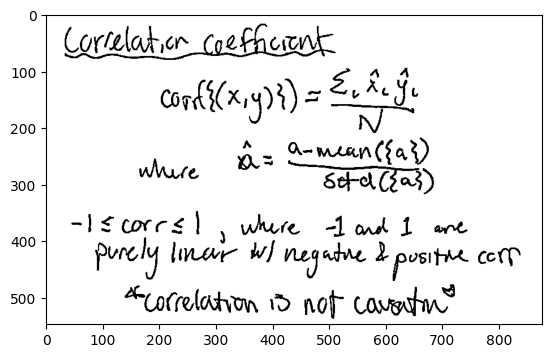

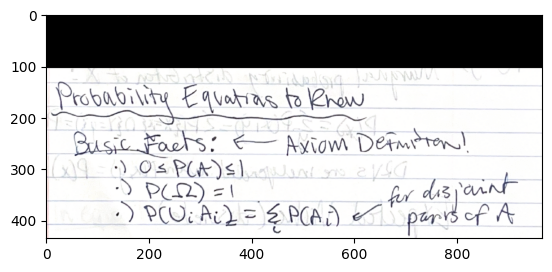

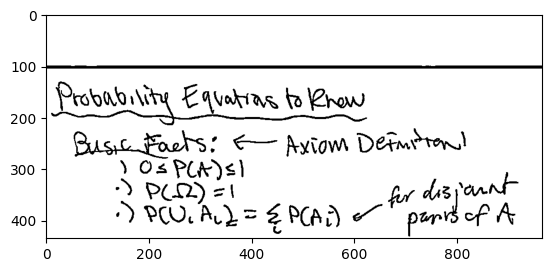

<Figure size 640x480 with 0 Axes>

In [26]:
image_paths = [
    r"images\full-slice-1.png",
    r"images\full-slice-2.png",
    r"images\full-slice-3.png",
]

for image_path in image_paths:
    image = cv2.imread(image_path)
    show_cv2_img(image)
    filtered = full_filter(image)
    plt.figure()
    plt.imshow(filtered, cmap='gray')
    plt.figure()

Yep that looks a lot better! 

I don't think that this type of conversion should be very compute-intensive, but I may have to time it and look into each function and its runtime more.

Unless doing that before on the whole page will result in better segmentation, I think we could just run this on each individual segment, or at least chunking each page up. Shouldn't be too demanding compute-wise, at least compared to the other models we'll be running.

That is something that I'll be concerned about going forward. If we're segmenting so much at once, it'll probably be pretty hard to do all that. Even adobe's text recognition takes a while with PDFs. So we'll see how performant we can get after the mock ups are designed.

We'll still stick with this YoloV11n-seg, OpenCV, TrOCR lineup for now. But there may be more performant approaches and models that I'll have to look into eventually.

# Continued Testing

I'm going to test it again, just to make sure it works with my main dataset! I'll also probably keep adding to this, eventually making it more complex to deal with the lines if needed. This can help work with pencil and other writing materials.

In [27]:
import os

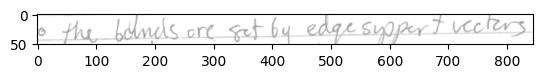

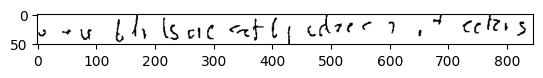

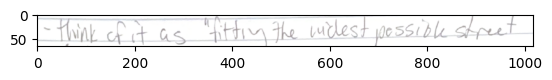

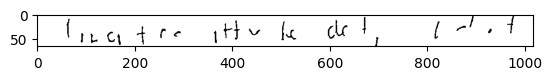

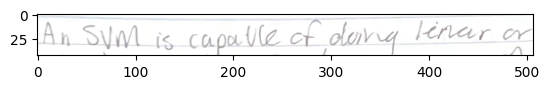

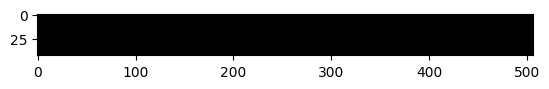

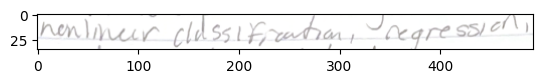

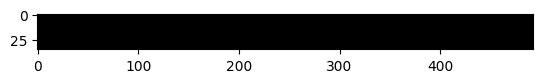

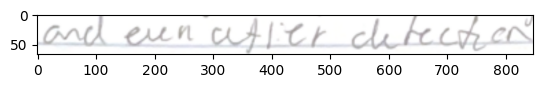

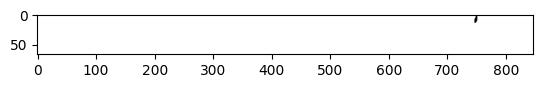

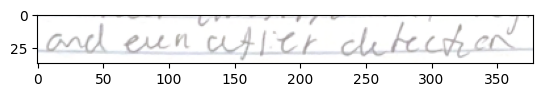

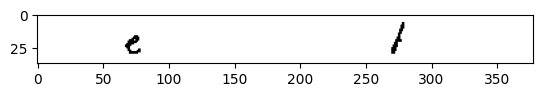

<Figure size 640x480 with 0 Axes>

In [28]:
new_page_dir = r'images\svm_page'
image_paths = [os.path.join(new_page_dir, file_name) for file_name in os.listdir(new_page_dir)]

for image_path in image_paths:
    image = cv2.imread(image_path)
    show_cv2_img(image)
    filtered = full_filter(image)
    plt.figure()
    plt.imshow(filtered, cmap='gray')
    plt.figure()

Yeah not looking good there. Let's try and figure this out, fix it.

In [29]:
def full_filter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    normalized = (255*(gray/gray.max())).astype(np.uint8)

    plt.figure()
    plt.imshow(normalized, cmap='gray')

    adapted = apply_adaptive_threshold(normalized)
    filtered = filter_specs(adapted)
    dilated = dilate(filtered)
    blurred = apply_blur(dilated)
    final = cv2.bitwise_not(blurred)
    return final
    

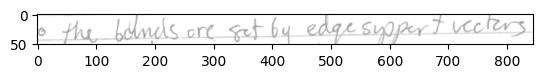

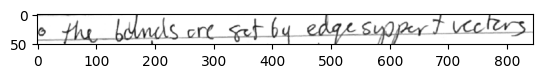

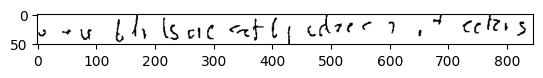

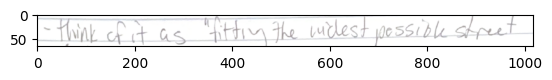

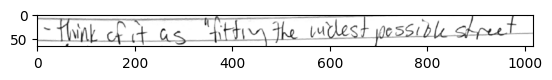

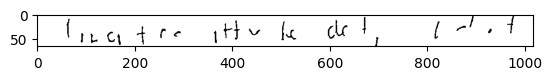

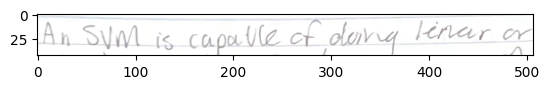

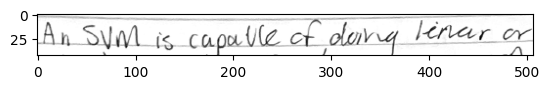

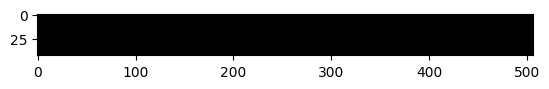

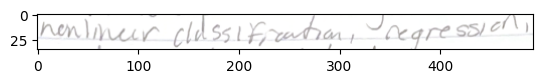

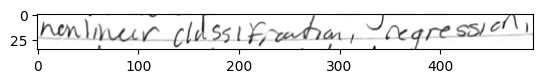

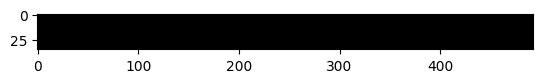

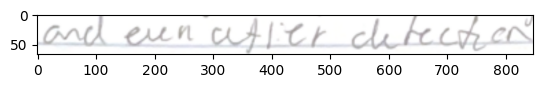

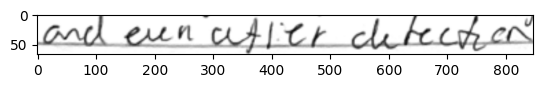

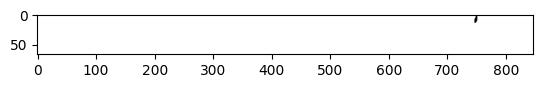

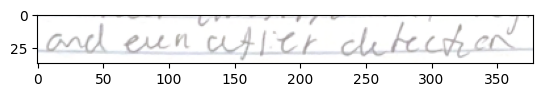

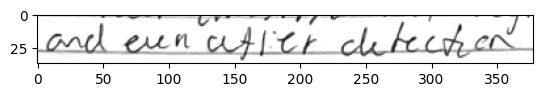

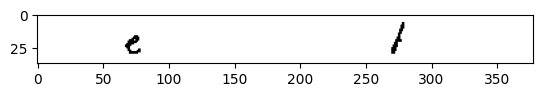

<Figure size 640x480 with 0 Axes>

In [30]:
new_page_dir = r'images\svm_page'
image_paths = [os.path.join(new_page_dir, file_name) for file_name in os.listdir(new_page_dir)]

for image_path in image_paths:
    image = cv2.imread(image_path)
    show_cv2_img(image)
    filtered = full_filter(image)
    plt.figure()
    plt.imshow(filtered, cmap='gray')
    plt.figure()

Still the same, interesting...

Let's see if the underlined text still is fine, that the model might be able to read around it.

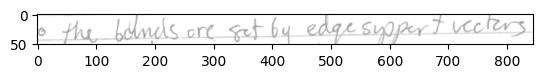

In [31]:
test_image_path = image_paths[0]
test_image = cv2.imread(test_image_path)
show_cv2_img(test_image)

In [32]:
def simple_filter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    normalized = (255 * (gray / gray.max()))

    plt.figure()
    plt.imshow(normalized, cmap='gray')

    return normalized

{'generated_text': 'other helmets are set by edge support vectors'}


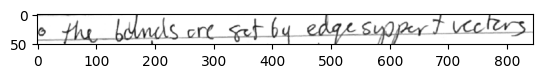

In [33]:
test_image_filtered = simple_filter(test_image)
result = transfer(test_image_path)[0]

print(result)

Interesting, it's looking at the bullet as an o. Might be worth not including those then. Thankfully though, it doesn't mind the lines (or at least from this one test). Let's test further!

In [34]:
def simple_test_image(image_path):
    image = cv2.imread(image_path)
    filtered = simple_filter(image)
    result = transfer(image_path)
    print(result[0]['generated_text'])

other helmets are set by edge support vectors


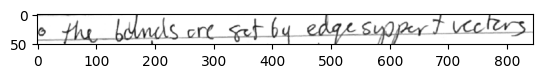

In [35]:
simple_test_image(test_image_path)

" think of it as " fitting the modest possible street . "


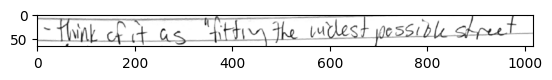

In [36]:
simple_test_image(image_paths[1])

Not bad, although 'modest' should be widest. Maybe there's a way to add context so that it can know what its talking about and know the terminology for more than just one sentence. Again, didn't get the bullet so should probably not include those (except for maybe segmenting as bullet point, then cropping out later?)

and even affect the historical


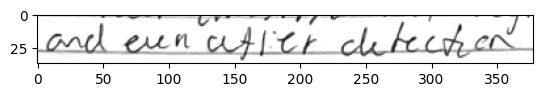

In [37]:
simple_test_image(image_paths[5])

This one's pretty rough... I wonder if it's the things above it?

and even , after detection


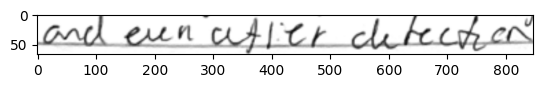

In [38]:
simple_test_image(r'images\svm_page\line-3-crop.png')

Better, but still not exactly right (it's outlier not after, but to be fair my handwriting is rough). Hopefully adding some context or something will help with that, will have to look into ways of improving the model. Maybe training on top with my handwriting, but that involves some annoying transcribing, segmentation will come first.

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


and even , after detection


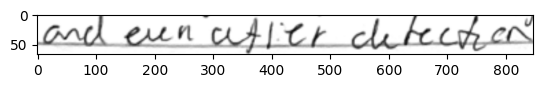

In [39]:
simple_test_image(image_paths[4])

# Refining Our Filtering

With the new information on the model's capabilities, it may be useful for now to just find a way to just keep the text and the lines. The only thing to filter out would be things bleeding through. But that shouldn't be too hard, probably just some function with a decent cutoff (after normalizing to 255). 

In [64]:
def simple_filter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    return normalized

def view_filter(image, f):
    # Original Performance
    pil_original = Image.fromarray(image)
    result_original = transfer(pil_original)
    print(result_original[0]['generated_text'])

    # Filter Image
    plt.imshow(image, cmap='gray')
    plt.show()
    filtered_image = f(image)
    plt.imshow(filtered_image, cmap='gray')
    plt.show()

    # Filtered Performance
    pil_filtered = Image.fromarray(filtered_image)
    result_filtered = transfer(pil_filtered)
    print(result_filtered[0]['generated_text'])


An SUN is capable of , doing linear or


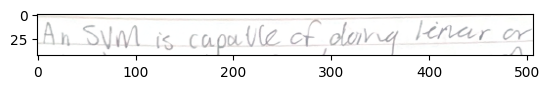

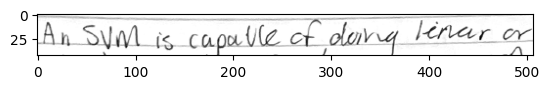

An SNN is capable of , doing linear or


In [81]:
test_image = cv2.imread(image_paths[2])
view_filter(test_image, simple_filter)

They probably have their own filtering built in, and just adding this might make it a little different but seemingly not by much. We'll see what else we can do.

In [92]:
def erode(image):
    return cv2.erode(
        image,
        np.ones((2, 2), np.uint8),
        iterations=1
    )

def involved_filter(image):
    normalized = simple_filter(image)
    eroded = erode(normalized)

    return eroded

An SUN is capable of , doing linear or


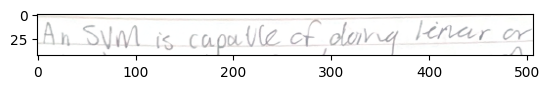

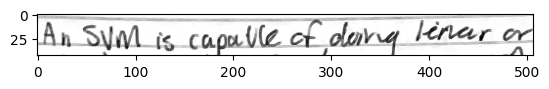

AN SNAL is capable of , daring linear or


In [93]:
view_filter(test_image, involved_filter)

The issue is that written text can have so many issues. Light pencil strokes, random pen mistakes, bleedthrough, etc. It seems like their audio filtering or dealing with is good enough for now. I'll see if I can just fine-tune this to make it better. 

Did a little research, the model's probably just good because of its structure and training data. Has the edge deteciton and all that from the models learning the features.

# Rethinking Approach

Since filtering outright isn't seeming all that important, let's see what is.

After some research (talking with an LLM mostly), some things I'd like to look into:

1. Add beams to let model explore further text for more options (non-greedy)
2. Resizing and padding some of my longer inputs that are much too long (and not tall enough)
3. Fine-Tuning

# Beams and Pads

## Beams

This is supposed to help with recognition, adding a higher number of beams lets the model look for that number of highest scoring token sequences. Usually with 1, it's greedy and just picking the next best token. But with num_beams, it's able to look at the next "num" highest probability tokens/sequences and kills low probability ones. Allows for early mistakes to not mess up the rest of translation.

I added num_beams=4, before it was greedy, so just one by default.

Here's the text (still not good:)

In [ ]:
"""
# the funny a macle 


- brid church , randomized search , others 
- meant to takeliest his performance 
- ONCE that think you like Pearl year best evaluate the small model on the F 
    - ausually will be worse than in cross\-rate especially at hyperfinealal of expont return 


- recommendations \. Good documentation , clear impact , aged communication 

# Launch  Monitor  Mountain 


- pleasant into pipeline 
- Tiested for the performance 
- elia himainevituation into impeche 
- evaluate input dates \. 
- Transportation regular basis 
    - conformate chemucha : nockments 
"""

<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:1: SyntaxWarning: invalid escape sequence '\-'
C:\Users\gjbur\AppData\Local\Temp\ipykernel_78884\2974826811.py:1: SyntaxWarning: invalid escape sequence '\-'
  """


'\n# the funny a macle \n\n\n- brid church , randomized search , others \n- meant to takeliest his performance \n- ONCE that think you like Pearl year best evaluate the small model on the F \n    - ausually will be worse than in cross\\-rate especially at hyperfinealal of expont return \n\n\n- recommendations \\. Good documentation , clear impact , aged communication \n\n# Launch  Monitor  Mountain \n\n\n- pleasant into pipeline \n- Tiested for the performance \n- elia himainevituation into impeche \n- evaluate input dates \\. \n- Transportation regular basis \n    - conformate chemucha : nockments \n'

Took around 63s. And with greedy:

In [97]:
"""
# the funny a mock 


- brid church , randomized search , others 
- meant to takeliest her performance 
- ONCE that think you like Pearl year best evaluate the small model on the F 
    - ausvatka will be worse than in cross\-val , espeerdling that hyperfimental of expont return 


- recommendations \. Good documentation , clear impact , aged communication 

# Launch  Monitor  Mountain 


- pleasant into pipeline 
- Tiesfield for the bottom\- 
- elia himainevituation into impeche 
- evaluate input dates 
- Train middleston regular basis 
    - carbonate chemucha : nockenzal \. 
"""

<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:1: SyntaxWarning: invalid escape sequence '\-'
C:\Users\gjbur\AppData\Local\Temp\ipykernel_78884\1684117182.py:1: SyntaxWarning: invalid escape sequence '\-'
  """


'\n# the funny a mock \n\n\n- brid church , randomized search , others \n- meant to takeliest her performance \n- ONCE that think you like Pearl year best evaluate the small model on the F \n    - ausvatka will be worse than in cross\\-val , espeerdling that hyperfimental of expont return \n\n\n- recommendations \\. Good documentation , clear impact , aged communication \n\n# Launch  Monitor  Mountain \n\n\n- pleasant into pipeline \n- Tiesfield for the bottom\\- \n- elia himainevituation into impeche \n- evaluate input dates \n- Train middleston regular basis \n    - carbonate chemucha : nockenzal \\. \n'

Took about 25s. And with num_beams=8

In [98]:
"""
# the funny a macle 


- brid church , randomized search , others 
- meant to takeliest his performance 
- ONCE that think you like Pearl year best evaluate the small model on the F 
    - ausually will be worse than in cross\-rate especially at hyperfinealal of expont return 


- recommendations \. Good documentation , clear impact , aged communication 

# Launch  Monitor  Mountain 


- pleasant into pipeline 
- treated for the better\-monetz 
- elia himainevituation into impeche 
- evaluate input dates \. 
- Transportation regular basis 
    - conformate chemucha : nockments
"""

<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:1: SyntaxWarning: invalid escape sequence '\-'
C:\Users\gjbur\AppData\Local\Temp\ipykernel_78884\966140105.py:1: SyntaxWarning: invalid escape sequence '\-'
  """


'\n# the funny a macle \n\n\n- brid church , randomized search , others \n- meant to takeliest his performance \n- ONCE that think you like Pearl year best evaluate the small model on the F \n    - ausually will be worse than in cross\\-rate especially at hyperfinealal of expont return \n\n\n- recommendations \\. Good documentation , clear impact , aged communication \n\n# Launch  Monitor  Mountain \n\n\n- pleasant into pipeline \n- treated for the better\\-monetz \n- elia himainevituation into impeche \n- evaluate input dates \\. \n- Transportation regular basis \n    - conformate chemucha : nockments\n'

In 135s. So not enough change at all to warrant using anything other than maybe 2. Scales around linearly, but in this that's a lot more time (4x, 8x)

So, I don't think this will be a good solution

## BGR Issue?

While doing some conversing with the LLM about padding, noticed I was using BGR. Might be something that could influence performance. Annoying that different libraries use different formats by default, but I should've known this could cause an issue because I know its a factor.

In [ ]:
"""
# thetinny a macle  


- brid search , randomized search , others 
- meant to takeliest hyperparameter's 
- ONCE Her think you've heard your best valuable the small model on the \. 
    - " Swallow will be worse than in cross\-val , especially at hunger funeral of 

## Then Forget Your Jahreen  


- recommendations \. Good documentation , clear impact , aged\-communication 

### aunch  Monitor  Mountain 


- program into pipeline 
- jestly for the bottom\-manz stop rot 
- RNA humanitarian into prophet 
- evaluate reputation 
- Transportation regular basis 
    - crotonate chemucha s possibly 
"""

Maybe a little better, will keep it


## Pads

It molds everything to something like 384x384, so much need some for longer lines

(65, 1018, 3)


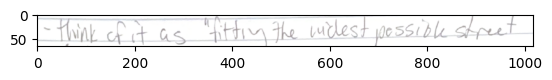

In [121]:
test_image = cv2.cvtColor(cv2.imread(image_paths[1]), cv2.COLOR_BGR2RGB)
print(test_image.shape)
plt.imshow(test_image)

This is already pretty bad, and its not even that long of a bullet! So let's do some padding. Was hand-writing a lot of this stuff, but I think at this point I'm going to start generating mostly, especially with these kind of workflows where the tools are what matters and the parameters I can adjust.

In [126]:
def find_best_single_cut(vertical_projection, start_x, end_x, height_threshold):
    """
    Scans a specific window range to find the absolute lowest ink column.
    If the lowest ink found still exceeds height_threshold, it flags it as a long word.
    """
    # Ensure indices stay within the image bounds
    start_x = max(0, start_x)
    end_x = min(len(vertical_projection), end_x)
    
    if start_x >= end_x:
        return start_x, False

    # Isolate the search slice
    search_zone = vertical_projection[start_x:end_x]
    local_cut_idx = np.argmin(search_zone)
    min_ink_val = search_zone[local_cut_idx]
    
    actual_cut_x = start_x + local_cut_idx
    
    # If the cleanest spot has too much ink, a long word is stretching through
    is_long_word = min_ink_val > height_threshold
    
    return int(actual_cut_x), is_long_word

def balance_and_plan_cuts(image, target_width=400, margin=60):
    """
    Accepts a raw OpenCV BGR image matrix.
    Computes balanced mid-sized cutting coordinates, avoiding long words.
    """
    # 1. Image preparation & projection calculation
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    vertical_projection = np.sum(thresh, axis=0)
    
    img_height, img_width = gray.shape
    
    # Calculate target chunks based on image width
    num_chunks = int(np.ceil(img_width / target_width))
    if num_chunks <= 1:
        return [0, img_width]
        
    ideal_step = img_width / num_chunks
    cut_points = [0]
    
    # Establish baseline threshold for solid words (5% height fill)
    height_threshold = img_height * 255 * 0.05
    
    for i in range(1, num_chunks):
        ideal_x = int(i * ideal_step)
        
        # Define search neighborhood to ensure mid-sized balance
        start_search = ideal_x - margin
        end_search = ideal_x + margin
        
        # Analyze the target zone
        cut_x, hitting_long_word = find_best_single_cut(
            vertical_projection, start_search, end_search, height_threshold
        )
        
        # Strategy Shift: If a long word is found, dynamically search outward
        if hitting_long_word:
            emergency_start = ideal_x + margin
            emergency_end = ideal_x + (margin * 3)
            
            backup_cut_x, still_blocked = find_best_single_cut(
                vertical_projection, emergency_start, emergency_end, height_threshold
            )
            
            # Use the clean alternative if it successfully exits the word boundary
            if not still_blocked and backup_cut_x < img_width:
                cut_x = backup_cut_x
            else:
                # Total fallback: split directly down the center line
                cut_x = ideal_x
                
        cut_points.append(cut_x)
        
    cut_points.append(img_width)
    return sorted(list(set(cut_points)))

def extract_chunks_from_plan(image, cut_points):
    """
    Takes the raw OpenCV image and the list of planned cut coordinates.
    Slices the image into segments with no additional padding.
    """
    image_chunks = []
    num_chunks = len(cut_points) - 1
    
    for i in range(num_chunks):
        start_x = cut_points[i]
        end_x = cut_points[i + 1]
        
        # Slice the matrix horizontally using the column bounds
        cropped_bgr = image[:, start_x:end_x]
        image_chunks.append(cropped_bgr)
            
    return image_chunks

def pad_chunks_to_square(image_chunks, bg_color=255):
    """
    Takes a list of sliced OpenCV BGR images and pads their top and bottom
    margins with white pixels until their height matches their width.
    """
    padded_chunks = []
    
    for chunk in image_chunks:
        h, w = chunk.shape[:2]
        
        if w > h:
            # Calculate total padding needed to make height match width
            pad_total = w - h
            top_pad = pad_total // 2
            bottom_pad = pad_total - top_pad
            
            # Apply uniform padding to the top and bottom borders
            padded_chunk = cv2.copyMakeBorder(
                chunk, 
                top_pad, 
                bottom_pad, 
                0, 0, # No padding on left or right
                borderType=cv2.BORDER_CONSTANT, 
                value=[bg_color, bg_color, bg_color]
            )
            padded_chunks.append(padded_chunk)
        else:
            # If the chunk is already square or taller than wide, keep it as-is
            padded_chunks.append(chunk)
            
    return padded_chunks

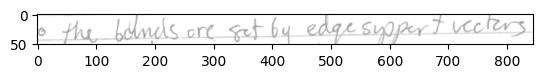

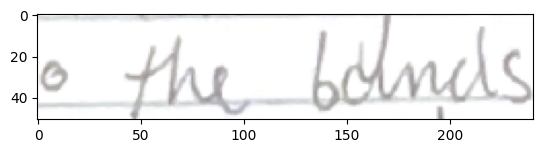

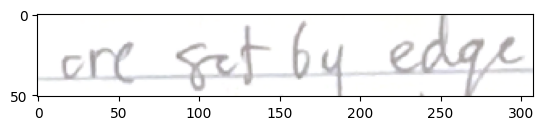

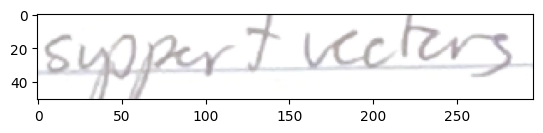

In [132]:
test_image = cv2.cvtColor(cv2.imread(image_paths[0]), cv2.COLOR_BGR2RGB)
cut_points = balance_and_plan_cuts(test_image)

plt.imshow(test_image)
plt.show()

image_chunks = extract_chunks_from_plan(test_image, cut_points)
for chunk in image_chunks:
    plt.imshow(chunk)
    plt.show()

Looks pretty good.

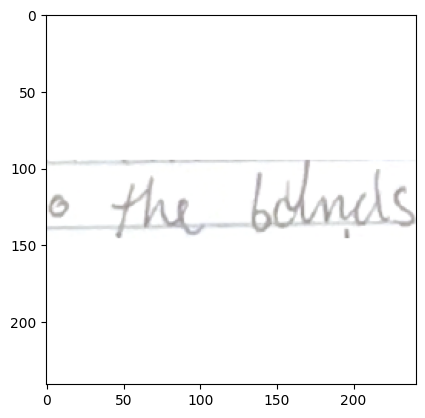

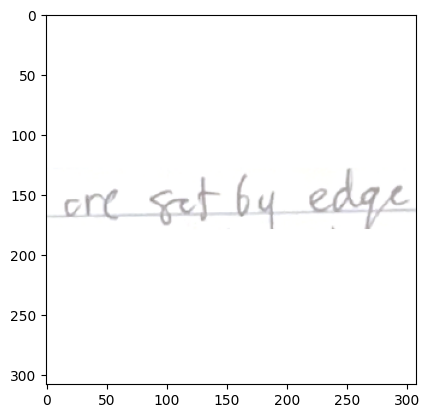

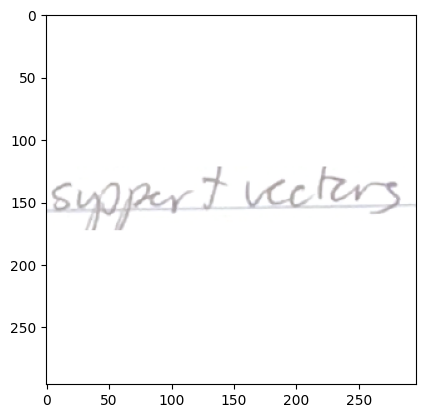

In [133]:
padded_chunks = pad_chunks_to_square(image_chunks)
for chunk in padded_chunks:
    plt.imshow(chunk)
    plt.show()

Yup, let's see if adding this to the overall pipeline will help.

In [134]:
def merge_text_chunks(text_chunks):
    """
    Takes a list of text strings extracted from sequential image chunks 
    and merges them seamlessly by deduplicating overlapping words at the seams.
    """
    if not text_chunks:
        return ""
        
    # Start with the text from the absolute first chunk
    combined_text = text_chunks[0].strip()
    
    for next_chunk in text_chunks[1:]:
        next_chunk = next_chunk.strip()
        if not next_chunk:
            continue
            
        words_combined = combined_text.split()
        words_next = next_chunk.split()
        
        # Find the longest matching sequence of words between the end of 
        # our accumulated text and the start of the incoming chunk
        matcher = difflib.SequenceMatcher(None, words_combined, words_next)
        match = matcher.find_longest_match(0, len(words_combined), 0, len(words_next))
        
        # Verify that the match happens at the boundary junction
        # (The match must end at the last word of combined_text OR start at the first word of words_next)
        if match.size > 0 and (match.a + match.size == len(words_combined) or match.b == 0):
            # Slice and merge at the overlapping juncture
            merged_words = words_combined[:match.a] + words_next[match.b:]
            combined_text = " ".join(merged_words)
        else:
            # Fallback if no clean linguistic overlap is detected
            combined_text += " " + next_chunk

    return combined_text

In [ ]:
"""
# timetemms  a mocket 


- good sumels \. 
- meant to tind , best here \# seven member \. ' 
- three units \. inside yourself Round semi worst mainaire the small magic \. " 
    - encordibles mini where worse than in cross\-vack , opposedments to work over signed a lot \. 

## Then Forget four sixteen  


- \# recommended to " good documentaries as clearer \. innouched \. demoncers and can 

### cunch  Maister Mountain  


- processurers to rise here 
- Tiesdale Fair 1 the Battermores \. ex stop set 
- isria minna neubulation in to impeble \. 
- evaluate 1 isout duties \. 
- France and solicits on reserve basis 
    - cow to make dhomacha s passible 
"""

In [ ]:
"""
# fivefunny  a model 


- berid search , conclamized sex \. ch , others \. 
- mermit to find best her perperimeter's 
- onell start \. frink youn't like Pennsylvania best variuation the fINALI model cnight his \. 
    - unsulating use Hype worse than in cross\-val , especially at the peri joined a lot \. 

## Then Forget tear dohtren  


- reccomperature " Good documentatz or spoken \. impact , good \. communication 

### aunch  Monitor Maunton  


- phaggery \. 
- jestly for 1 the better\-manee exemptment 
- phig NJ " nevitification in to prevent 
- evaluate , input\-olation 
- trans\-man\- an regular basis 
    - conformate dhemuchs \. possibly 
"""

No just doesn't seem good at all. Let's try to fine-tune then

# Fine-Tuning

## Get Dataset

Have to get the by-line images, and then classify them (will try out using Antigravity since that's all I have right now)

In [5]:
original_images = r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line-12-19\data\images\train"
original_labels = r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\refined-two-step\by-line-12-19\data\labels\train"

In [8]:
def crop_from_bb(image, xyxy):
    x1, y1, x2, y2 = xyxy
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    return image[y1:y2+1, x1:x2+1]

def parse_yolo_to_xyxy_list(label_file_path, img_width, img_height):
    """
    Parses a YOLOv11 label file and returns only the un-normalized 
    bounding box coordinates as a list of lists [[xmin, ymin, xmax, ymax], ...]
    """
    boxes = []
    
    with open(label_file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            parts = line.split()
            cx, cy, w, h = map(float, parts[1:5])
            
            xmin = max(0, int((cx - (w / 2)) * img_width))
            ymin = max(0, int((cy - (h / 2)) * img_height))
            xmax = min(img_width, int((cx + (w / 2)) * img_width))
            ymax = min(img_height, int((cy + (h / 2)) * img_height))
            
            boxes.append([xmin, ymin, xmax, ymax])
            
    return boxes

counter = 0
output_directory = r"C:\Users\gjbur\Desktop\Code\note-transfer\development\datasets\fine-tuning\lines"

for image_name, label_name in zip(os.listdir(original_images), os.listdir(original_labels)):
    image_path = os.path.join(original_images, image_name)
    image = cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    label_path = os.path.join(original_labels, label_name)
    xyxys = parse_yolo_to_xyxy_list(label_path, image.shape[1], image.shape[0])

    for xyxy in xyxys:
        cropped_image = crop_from_bb(image, xyxy)

        if not (cropped_image.shape[1] < 75 or cropped_image.shape[1]/cropped_image.shape[0] < 1.5):
            counter += 1 
            output_path = os.path.join(output_directory, f"line_{counter}.jpg")
            cv2.imwrite(output_path, cropped_image)
            # plt.imshow(cropped_image)
            # plt.show()

print(counter)


436


Ended up having to delete some of the graphs, bullets, etc. And then antigravity was really bad, so I ended up having it create an interface for me to quickly label the data. That worked out pretty well.